In [1]:
import os 
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd 
import numpy as np
from sklearn import tree
import graphviz
from src.model_utils import load_model, train_model, save_model, tune_model
from src.preprocessor_utils import convert_time_to_hour
from src.eval_metric import f1_benchmark, AUPRC, evaluate_model
from src.plot import plot_confusion_matrix_percent,plot_prediction_distribution, find_optimal_threshold,shapBeewarm,plot_force_shap
import joblib

d:\anaconda\envs\tf_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = os.path.join(project_root,"data","train_goc.csv")
df = pd.read_csv(data_path)
test_path = os.path.join(project_root,"data",'test_goc.csv')
df_test = pd.read_csv(test_path)

x_t = df_test.drop('Class',axis = 1)
y_test = df_test['Class']

x = df.drop('Class', axis = 1)
y_train = df['Class']

preprocessor_path = os.path.join(project_root,"data","creditcard_preprocessor.pkl")
preprocessor = joblib.load(preprocessor_path)

x_train = preprocessor.transform(x)
x_test = preprocessor.transform(x_t)

In [16]:
path_dc = os.path.join(project_root,"models","model_dc_opt.pkl")
path_rf = os.path.join(project_root,"models","model_rcv_rf_raw.pkl")
path_xgb = os.path.join(project_root,'models',"model_xgb_opt_raw.pkl")
path_nb_opt = os.path.join(project_root,"models","model_nb_opt_raw.pkl")
path_lr = os.path.join(project_root,"models","model_lr_opt_raw.pkl")

In [17]:
model_dc = joblib.load(path_dc)
model_rf = joblib.load(path_rf)
model_xgb = joblib.load(path_xgb)
model_nb = joblib.load(path_nb_opt)
model_lr = joblib.load(path_lr)


In [12]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score
)

def evaluate_saved_models(model_files, X_test, y_test, threshold=0.5):
    """
    So sánh nhiều mô hình đã được train và lưu file .pkl.
    
    model_files: dict {"ModelName": "models/models_xgb.pkl"}
    threshold  : ngưỡng phân loại fraud
    
    Trả về DataFrame kết quả.
    """
    results = []

    for name, file_path in model_files.items():
        print(f"=== Đang load model: {name} ===")

        # Load model
        model = joblib.load(file_path)

        # Dự đoán xác suất
        if hasattr(model[0], "predict_proba"):
            y_prob = model[0].predict_proba(X_test)[:, 1]
        else:
            y_prob = model[0].decision_function(X_test)

        # Áp ngưỡng
        y_pred = (y_prob >= threshold).astype(int)

        # Tính metric
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall    = recall_score(y_test, y_pred, zero_division=0)
        f1        = f1_score(y_test, y_pred, zero_division=0)

        # F2-score (quan trọng cho fraud detection)
        beta = 2
        f2 = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-9)

        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc  = average_precision_score(y_test, y_prob)

        results.append({
            "Model": name,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "F2": f2,
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc
        })

    return pd.DataFrame(results).sort_values("F2", ascending=False)


In [20]:
models = {
    "Decision Tree": path_dc,
    "Random Forest": path_rf,
    "XGBoost": path_xgb,
    "Naive Bayes": path_nb_opt
}


In [21]:
result_df = evaluate_saved_models(models, x_test, y_test, threshold=0.5)
result_df

=== Đang load model: Decision Tree ===
=== Đang load model: Random Forest ===
=== Đang load model: XGBoost ===
=== Đang load model: Naive Bayes ===


,Model,Precision,Recall,F1,F2,ROC-AUC,PR-AUC
2,XGBoost,0.935065,0.757895,0.837209,0.787746,0.976267,0.827168
1,Random Forest,0.736264,0.705263,0.720430,0.711253,0.862894,0.620489
0,Decision Tree,0.876712,0.673684,0.761905,0.706402,0.913295,0.713023
3,Naive Bayes,0.057549,0.810526,0.107467,0.224098,0.946321,0.076060


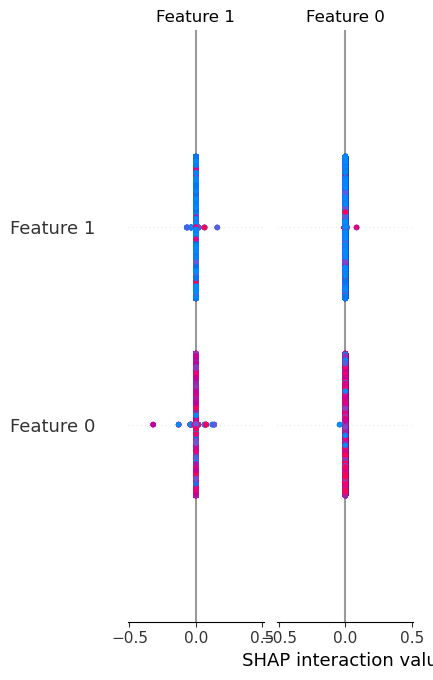

In [15]:
shapBeewarm(model_dc[0],x_test)

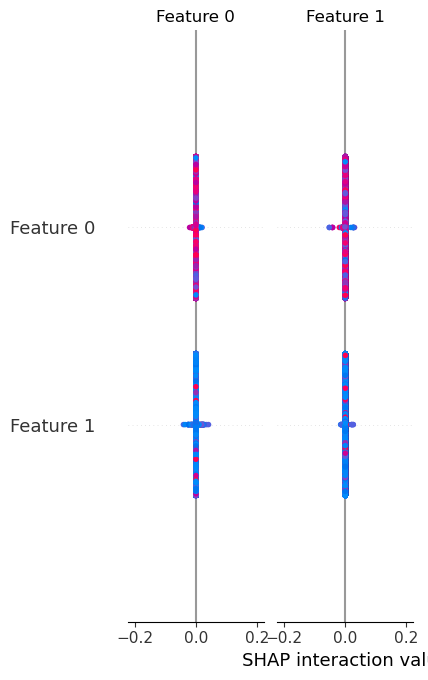

In [23]:
shapBeewarm(model_rf,x_test)